In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import re

In [2]:
df = pd.read_csv("../data/laptop.csv")

## Exploring Data

In [3]:
df.head()

,Unnamed: 0,Model,Price,Rating,Generation,Core,Ram,SSD,Display,Graphics,OS,Warranty
0,0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,"₹50,399",70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8 GB DDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels, Touch Screen",4 GB AMD Radeon RX 6500M,Windows 11 OS,1 Year Warranty
1,1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,"₹23,990",56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8 GB LPDDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",Intel UHD Graphics,Windows 11 OS,1 Year Warranty
2,2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,"₹26,989",55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads",8 GB LPDDR5 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",AMD Radeon Graphics,Windows 11 OS,1 Year Warranty
3,3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,"₹69,990",60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16 GB LPDDR5 RAM,512 GB SSD,"13.3 inches, 1080 x 1920 pixels",Intel Iris Xe Graphics,Windows 11 OS,1 Year Warranty
4,4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,"₹1,02,990",78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads",16 GB DDR5 RAM,1 TB SSD,"16.1 inches, 2560 x 1600 pixels",8 GB NVIDIA GeForce RTX 4060,Windows 11 OS,1 Year Warranty


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  920 non-null    int64  
 1   Model       920 non-null    object 
 2   Price       920 non-null    object 
 3   Rating      768 non-null    float64
 4   Generation  920 non-null    object 
 5   Core        920 non-null    object 
 6   Ram         920 non-null    object 
 7   SSD         920 non-null    object 
 8   Display     919 non-null    object 
 9   Graphics    920 non-null    object 
 10  OS          919 non-null    object 
 11  Warranty    915 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 86.4+ KB


## Data Cleaning

In [4]:
df.head()

,Unnamed: 0,Model,Price,Rating,Generation,Core,Ram,SSD,Display,Graphics,OS,Warranty
0,0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,"₹50,399",70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8 GB DDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels, Touch Screen",4 GB AMD Radeon RX 6500M,Windows 11 OS,1 Year Warranty
1,1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,"₹23,990",56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8 GB LPDDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",Intel UHD Graphics,Windows 11 OS,1 Year Warranty
2,2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,"₹26,989",55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads",8 GB LPDDR5 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",AMD Radeon Graphics,Windows 11 OS,1 Year Warranty
3,3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,"₹69,990",60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16 GB LPDDR5 RAM,512 GB SSD,"13.3 inches, 1080 x 1920 pixels",Intel Iris Xe Graphics,Windows 11 OS,1 Year Warranty
4,4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,"₹1,02,990",78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads",16 GB DDR5 RAM,1 TB SSD,"16.1 inches, 2560 x 1600 pixels",8 GB NVIDIA GeForce RTX 4060,Windows 11 OS,1 Year Warranty


In [6]:
df = df.drop(['Unnamed: 0'], axis=1) #delete unecessary column

In [7]:
df = df.rename(columns={"Price": "Price (₹)"})

In [8]:
df.head()

,Model,Price (₹),Rating,Generation,Core,Ram,SSD,Display,Graphics,OS,Warranty
0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,"₹50,399",70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8 GB DDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels, Touch Screen",4 GB AMD Radeon RX 6500M,Windows 11 OS,1 Year Warranty
1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,"₹23,990",56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8 GB LPDDR4 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",Intel UHD Graphics,Windows 11 OS,1 Year Warranty
2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,"₹26,989",55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads",8 GB LPDDR5 RAM,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",AMD Radeon Graphics,Windows 11 OS,1 Year Warranty
3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,"₹69,990",60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16 GB LPDDR5 RAM,512 GB SSD,"13.3 inches, 1080 x 1920 pixels",Intel Iris Xe Graphics,Windows 11 OS,1 Year Warranty
4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,"₹1,02,990",78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads",16 GB DDR5 RAM,1 TB SSD,"16.1 inches, 2560 x 1600 pixels",8 GB NVIDIA GeForce RTX 4060,Windows 11 OS,1 Year Warranty


In [9]:
df['Price (₹)'] = df['Price (₹)'].str.replace('₹', '')
df['Price (₹)'] = df['Price (₹)'].str.replace(',', '')
df['Price (₹)'] = df['Price (₹)'].astype(int)


In [10]:
df['Ram'] = df['Ram'].str.extract('(^\d+)')

In [11]:
df[df['Ram'].isnull()]

,Model,Price (₹),Rating,Generation,Core,Ram,SSD,Display,Graphics,OS,Warranty
109,Samsung Galaxy Book2 15 Laptop (12th Gen Core ...,49990,NaN,Processor: 12th Generation Intel Core i5-1235U...,Memory: 8 GB LPDDR4 Memory (On BD 8 GB),NaN,Operating System: Windows 11 Home,Display: 15.6 inch (39.6 cm),Preinstalled Software: MS Office Home & Studen...,Intel Iris Xe Graphics,Ports: 1 HDMI


In [12]:
df = df.drop([109])
df['Ram'] = df['Ram'].astype(int)

In [13]:
df['SSD'].unique()

array(['512\u2009GB SSD', '1\u2009TB SSD', '256\u2009GB SSD',
       '2\u2009TB SSD', '16\u2009GB NVIDIA GeForce RTX 4090',
       '1\u2009TB Hard Disk', '128\u2009GB SSD', '32\u2009GB Hard Disk',
       'Intel Arc Graphics', '8\u2009GB NVIDIA GeForce RTX 4060',
       '128\u2009GB Hard Disk',
       '14\u2009inches, 2160\u2009x\u20091440\u2009pixels',
       '11.6\u2009inches, 1366\u2009x\u2009768\u2009pixels',
       '4\u2009TB SSD', '64\u2009GB SSD', '64\u2009GB Hard Disk',
       '8\u2009GB NVIDIA GeForce RTX 4070'], dtype=object)

In [14]:
df = df.drop(df[df['SSD'].isin(['8\u2009GB NVIDIA GeForce RTX 4070', '16\u2009GB NVIDIA GeForce RTX 4090', 'Intel Arc Graphics', '8\u2009GB NVIDIA GeForce RTX 4060',
                   '14\u2009inches, 2160\u2009x\u20091440\u2009pixels', '11.6\u2009inches, 1366\u2009x\u2009768\u2009pixels'])].index)

### Handling 'Warranty' column

In [15]:
df['Warranty'].unique()

array(['1 Year Warranty', nan, 'Windows 11 OS', '2 Year Warranty',
       '3 Year Warranty', 'Backlit Keyboard', '1 USB 3.0 Ports',
       '2 USB 3.0 Ports'], dtype=object)

In [16]:
df = df[df['Warranty'] !='Backlit Keyboard'] #Drop rows that contain incorrect data

In [17]:
df = df.drop((df[df['Warranty'] == '1 USB 3.0 Ports']).index)
df = df.drop((df[df['Warranty'] == '2 USB 3.0 Ports']).index)

df['Warranty'].value_counts()

Warranty
1 Year Warranty    806
2 Year Warranty     74
3 Year Warranty     16
Windows 11 OS        5
Name: count, dtype: int64

In [18]:
target_idxs = df[df['Warranty']=='Windows 11 OS'].index

In [20]:
df.loc[target_idxs]

,Model,Price (₹),Rating,Generation,Core,Ram,SSD,Display,Graphics,OS,Warranty
84,MSI Thin GF63 11UC-1490IN Gaming Laptop (11th ...,52990,69.0,11th Gen Intel Core i5 11260H,"Hexa Core, 12 Threads",16,1 TB Hard Disk,4 GB NVIDIA GeForce RTX 3050,256 GB SSD,Windows 11 OS,"15.6 inches, 1920 x 1080 pixels"
327,MSI Thin GF63 11UC-1494IN Gaming Laptop (11th ...,63500,65.0,11th Gen Intel Core i7 11800H,"Octa Core, 16 Threads",16,1 TB Hard Disk,4 GB NVIDIA GeForce RTX 3050,256 GB SSD,Windows 11 OS,"15.6 inches, 1920 x 1080 pixels"
597,MSI Thin GF63 11UCX-1492IN Gaming Laptop (11th...,56990,69.0,11th Gen Intel Core i5 11260H,"Hexa Core, 12 Threads",16,1 TB Hard Disk,4 GB NVIDIA GeForce RTX 2050,256 GB SSD,Windows 11 OS,"15.6 inches, 1920 x 1080 pixels"
598,MSI Thin GF63 11UCX-1491IN Gaming Laptop (11th...,61990,71.0,11th Gen Intel Core i5 11260H,"Hexa Core, 12 Threads",16,1 TB Hard Disk,4 GB NVIDIA GeForce RTX 2050,512 GB SSD,Windows 11 OS,"15.6 inches, 1920 x 1080 pixels"
772,‎HP Zbook Power G4-A 2023 ZHAN 99 Laptop (AMD ...,115558,68.0,6th Gen AMD Ryzen 5 6600H,"Hexa Core, 12 Threads",16,1 TB Hard Disk,4 GB ‎NVIDIA Quadro T600,512 GB SSD,Windows 11 OS,"15.6 inches, 1920 x 1080 pixels"


In [19]:
df.loc[target_idxs, 'OS'], df.loc[target_idxs, 'Warranty'] = df.loc[target_idxs, 'Warranty'], df.loc[target_idxs, 'OS']

In [21]:
df.loc[target_idxs, 'Graphics'], df.loc[target_idxs, 'Warranty'] = df.loc[target_idxs, 'Warranty'], df.loc[target_idxs, 'Graphics']

In [22]:
df.loc[target_idxs, 'SSD'], df.loc[target_idxs, 'Warranty'] = df.loc[target_idxs, 'Warranty'], df.loc[target_idxs, 'SSD']

In [23]:
df.loc[target_idxs, 'Graphics'], df.loc[target_idxs, 'Display'] = df.loc[target_idxs, 'Display'], df.loc[target_idxs, 'Graphics']

In [24]:
df.loc[target_idxs, 'Warranty'] = 0

In [26]:
df['Warranty'].value_counts()

Warranty
1    806
2     74
3     16
Name: count, dtype: int64

In [25]:
df['Warranty'] = df['Warranty'].str.extract('(^\d+)')
df.head()

,Model,Price (₹),Rating,Generation,Core,Ram,SSD,Display,Graphics,OS,Warranty
0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,50399,70.0,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8,512 GB SSD,"15.6 inches, 1920 x 1080 pixels, Touch Screen",4 GB AMD Radeon RX 6500M,Windows 11 OS,1
1,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,56.0,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",Intel UHD Graphics,Windows 11 OS,1
2,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,26989,55.0,7th Gen AMD Ryzen 3 7320U,"Quad Core, 8 Threads",8,512 GB SSD,"15.6 inches, 1920 x 1080 pixels",AMD Radeon Graphics,Windows 11 OS,1
3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,69990,60.0,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16,512 GB SSD,"13.3 inches, 1080 x 1920 pixels",Intel Iris Xe Graphics,Windows 11 OS,1
4,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,102990,78.0,14th Gen Intel Core i9 14900HX,"24 Cores (8P + 16E), 32 Threads",16,1 TB SSD,"16.1 inches, 2560 x 1600 pixels",8 GB NVIDIA GeForce RTX 4060,Windows 11 OS,1


### Cleaming 'OS' column

In [28]:
df['OS'].value_counts()

OS
Windows 11 OS        845
Mac OS                18
DOS OS                15
Chrome OS              9
Windows 10 OS          6
Windows OS             4
Ubuntu OS              2
Windows 11 Pro OS      1
Backlit Keyboard       1
DOS 3.0 OS             1
1 Year Warranty        1
Name: count, dtype: int64

In [27]:
df['OS'] = df['OS'].str.replace('  ', ' ')

In [29]:
df = df[df['OS'] != '1 Year Warranty'] 
df['Warranty'] = df['Warranty'].fillna(0)
df['Warranty'] = df['Warranty'].astype(int)
df['Warranty'].value_counts()

Warranty
1    806
2     74
3     16
0      6
Name: count, dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 902 entries, 0 to 919
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Model       902 non-null    object 
 1   Price (₹)   902 non-null    int32  
 2   Rating      757 non-null    float64
 3   Generation  902 non-null    object 
 4   Core        902 non-null    object 
 5   Ram         902 non-null    int32  
 6   SSD         902 non-null    object 
 7   Display     902 non-null    object 
 8   Graphics    902 non-null    object 
 9   OS          902 non-null    object 
 10  Warranty    902 non-null    int32  
dtypes: float64(1), int32(3), object(7)
memory usage: 74.0+ KB


## Transforming Data

In [31]:
def transform_into_gigabytes(val):
    if pd.isna(val):
        return val

    vol = re.search(r'(^\d+)', str(val))
    if vol:
        vol = int(vol.group(0))
        if 'GB' in val: 
            return vol
        if 'TB' in val:
            return vol * 1024
    return None

df['SSD'] = df['SSD'].apply(transform_into_gigabytes)

In [32]:
df = df.rename(columns={'SSD': 'Storage'})

## Filling in the rating data

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 902 entries, 0 to 919
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Model       902 non-null    object 
 1   Price (₹)   902 non-null    int32  
 2   Rating      757 non-null    float64
 3   Generation  902 non-null    object 
 4   Core        902 non-null    object 
 5   Ram         902 non-null    int32  
 6   Storage     902 non-null    int64  
 7   Display     902 non-null    object 
 8   Graphics    902 non-null    object 
 9   OS          902 non-null    object 
 10  Warranty    902 non-null    int32  
dtypes: float64(1), int32(3), int64(1), object(6)
memory usage: 74.0+ KB


<Axes: >

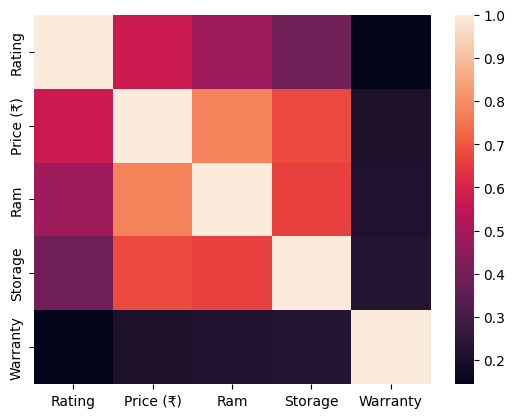

In [34]:
sns.heatmap(data=df[['Rating', 'Price (₹)', 'Ram', 'Storage', 'Warranty']].corr())

In [35]:
df['Rating'].describe()

count    757.000000
mean      61.782034
std        7.145968
min       50.000000
25%       56.000000
50%       62.000000
75%       66.000000
max       79.000000
Name: Rating, dtype: float64

In [36]:
df['Rating'] = df['Rating'].fillna(df.groupby('Ram')['Rating'].transform('median'))

In [37]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

In [38]:
df.to_csv('../data/laptop_cleaned.csv', index=False)